# 04 — Calibration, and a back-transform that reversed a conclusion

Ranking and calibration answer different questions. Notebook 03 showed the affinity head
ranks binders above non-binders at AUC ≈ 0.71. This notebook asks the other question — how
close is the predicted potency to the measured one — and finds a spreadsheet bug in the
original answer.

In [1]:
import sys, os
from pathlib import Path

# Work from the repository root wherever the notebook is launched from.
_root = Path.cwd().resolve()
while not (_root / "src" / "offtarget").exists():
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / "src"))

import numpy as np
import pandas as pd
from offtarget.transforms import (LOG10_E, affinity_to_uM, calibration_table,
                                  load_paired_affinities, log_error, workbook_legacy_uniprot)
pd.set_option("display.width", 140)
paired = load_paired_affinities("data/boltz_outputs/boltz2_result.xlsx")
paired.head()

,Target,drug,pdb_affinity,pdb_confidence,uni_affinity,uni_confidence,actual_uM
0,ADRA1A,Azatadine,-1.621722,0.917497,-0.754796,0.763111,8.642
1,ADRA1A,Domperidone,-1.569887,0.915596,-1.324721,0.778788,0.128
2,ADRA1A,Dyclonine,-0.114217,0.907724,0.076932,0.743779,9.658
3,ADRA1A,Ketotifen,-1.562104,0.914491,-1.711310,0.754783,10.379
4,ADRA1A,Meperidine,-0.493069,0.922222,-0.255173,0.773836,2.560


## The bug, in the file

`boltz2_result.xlsx` holds the PDB run and the UniProt run side by side. Column H
back-transforms the PDB arm's affinity; column O back-transforms the UniProt arm's. They are
the same quantity — Boltz-2's predicted log₁₀(IC50) in µM — and they are transformed
differently:

```
H2  =POWER(10,E2)      <- PDB arm
O2  =EXP(M2)           <- UniProt arm
```

Spot-check on ADRA1A / Azatadine, against the numbers stored in the sheet:

In [2]:
row = paired[(paired.Target == "ADRA1A") & paired.drug.str.contains("Azatadine", case=False)].iloc[0]
pd.DataFrame([
    {"arm": "PDB", "affinity output": row.pdb_affinity,
     "workbook transform": "POWER(10,x)", "workbook value µM": 10 ** row.pdb_affinity},
    {"arm": "UniProt", "affinity output": row.uni_affinity,
     "workbook transform": "EXP(x)", "workbook value µM": np.exp(row.uni_affinity)},
    {"arm": "UniProt", "affinity output": row.uni_affinity,
     "workbook transform": "POWER(10,x) — correct", "workbook value µM": 10 ** row.uni_affinity},
]).round(4)

,arm,affinity output,workbook transform,workbook value µM
0,PDB,-1.6217,"POWER(10,x)",0.0239
1,UniProt,-0.7548,EXP(x),0.4701
2,UniProt,-0.7548,"POWER(10,x) — correct",0.1759


## Why it flatters the UniProt arm

`eˣ = 10^(log₁₀(e)·x)`, and log₁₀(e) = 0.4343. Taking the exponential of a number that is
already a log₁₀ returns a value whose log₁₀ is 0.4343·x: every prediction is pulled toward
1 µM. Predictions are wrong mostly by being far from 1 µM, so the reported error shrinks
without the model changing at all.

In [3]:
x = paired.uni_affinity.dropna()
assert np.allclose(np.log10(workbook_legacy_uniprot(x)), LOG10_E * x)
print(f"log10(exp(x)) == {LOG10_E:.4f} * x   — exactly, for every row")

log10(exp(x)) == 0.4343 * x   — exactly, for every row


## What it did to the conclusion

In [4]:
calibration_table(paired).round(3)

,arm,transform,mean_abs_log10_error,n,fold_error
0,UniProt,EXP(x) - as computed in the workbook,0.898,119,7.907
1,UniProt,10**x - consistent,1.244,119,17.532
2,PDB,10**x - consistent,1.232,119,17.072


| Mean \|log₁₀ error\| vs measured activity | Value | Fold error |
|---|---|---|
| UniProt, as computed in the workbook (log₁₀ of eˣ) | **0.898** | 7.9× |
| UniProt, consistent transform | 1.244 | 17.5× |
| PDB, consistent transform | 1.232 | 17.1× |

The workbook reported 0.898 against 1.232 and concluded the UniProt arm was more accurate.
On a consistent transform the arms are 1.244 and 1.232 — a difference of 0.012 log units,
in the other direction. **The reported conclusion disappears and marginally reverses.**

In [5]:
d = paired.dropna(subset=["actual_uM", "pdb_affinity", "uni_affinity"])
d = d[d.actual_uM > 0]
ratio = (log_error(workbook_legacy_uniprot(d.uni_affinity), d.actual_uM).mean() /
         log_error(affinity_to_uM(d.uni_affinity), d.actual_uM).mean())
print(f"observed compression of the reported error: {ratio:.3f}x   (n = {len(d)})")

observed compression of the reported error: 0.722x   (n = 119)


Note that the observed compression of the *mean absolute error* is 0.722, not 0.4343. The
0.4343 factor applies exactly to the predicted log-concentration; the error also contains
the measured value, which the transform does not touch. The exact identity is the one
asserted above and in `tests/test_transforms.py`, not a ratio of error means.

## The calibration result itself

On the correct transform, mean absolute error is **≈1.23 log₁₀ units on both arms — about
17-fold** — over 119 pairs with a measured activity.

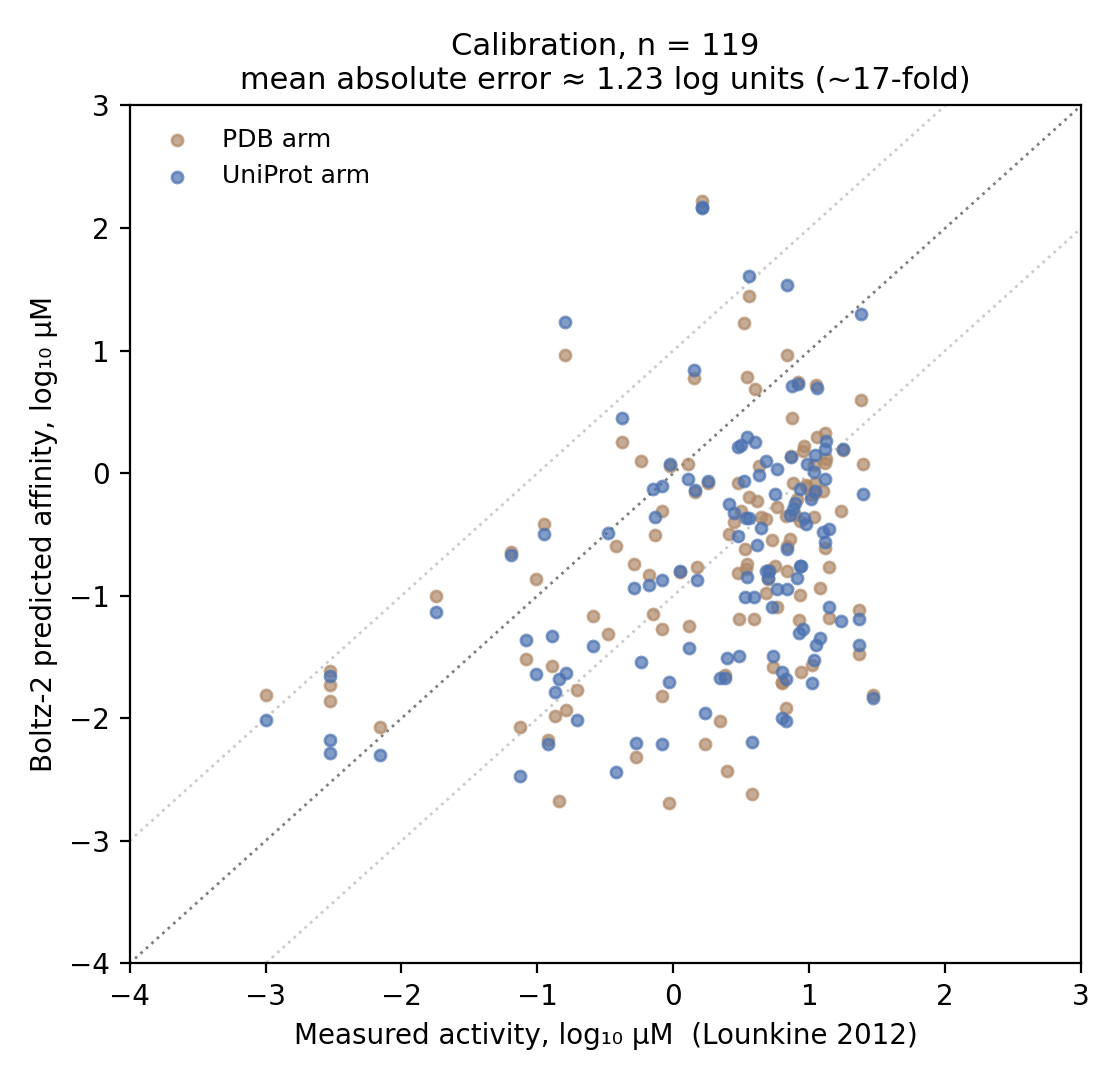

In [6]:
from offtarget import figures as F
from IPython.display import Image, display
F.calibration_scatter(paired, Path("results/figures/fig3_calibration.png"))
display(Image("results/figures/fig3_calibration.png"))

AUC ≈ 0.71 and 17-fold mean error are not in tension; they answer different questions. The
model puts binders above non-binders more often than not, *and* its absolute potency
predictions are off by more than an order of magnitude. A ranking that works does not imply
a number you can act on.